In [ ]:
import pandas as pd

df = pd.read_csv('/content/merged_data.csv')
df['Date'] = pd.to_datetime(df['Date'])
display(df.head())
display(df.tail())

,Date,E&E Exports,CPI Inflation,Exchange Rate,US Industrial Production Index
0,1990-01-01,1010.235516,0.7,2.7041,61.7290
1,1990-02-01,1034.736320,0.5,2.7032,62.2896
2,1990-03-01,1249.333470,-0.2,2.7170,62.5999
3,1990-04-01,1025.820057,0.4,2.7264,62.4359
4,1990-05-01,1223.404799,0.5,2.7024,62.6258


,Date,E&E Exports,CPI Inflation,Exchange Rate,US Industrial Production Index
418,2024-11-01,39795.672590,-0.1,4.4342,99.2925
419,2024-12-01,47002.306925,0.1,4.4579,100.3273
420,2025-01-01,40494.054767,0.1,4.4620,100.0647
421,2025-02-01,36504.760024,0.4,4.4408,101.0993
422,2025-03-01,45813.712073,0.0,4.4325,101.0404


In [ ]:
df['Target_1M'] = df['E&E Exports'].shift(-1)
df['Target_2M'] = df['E&E Exports'].shift(-2)
df['Target_3M'] = df['E&E Exports'].shift(-3)

In [ ]:
df[['Date', 'E&E Exports', 'Target_1M', 'Target_2M', 'Target_3M']].tail(10)

,Date,E&E Exports,Target_1M,Target_2M,Target_3M
413,2024-06-01,41083.016724,39357.590921,39863.748126,44006.856395
414,2024-07-01,39357.590921,39863.748126,44006.856395,39226.126364
415,2024-08-01,39863.748126,44006.856395,39226.126364,39795.672590
416,2024-09-01,44006.856395,39226.126364,39795.672590,47002.306925
417,2024-10-01,39226.126364,39795.672590,47002.306925,40494.054767
418,2024-11-01,39795.672590,47002.306925,40494.054767,36504.760024
419,2024-12-01,47002.306925,40494.054767,36504.760024,45813.712073
420,2025-01-01,40494.054767,36504.760024,45813.712073,NaN
421,2025-02-01,36504.760024,45813.712073,NaN,NaN
422,2025-03-01,45813.712073,NaN,NaN,NaN


In [ ]:
df['E&E Lag 1'] = df['E&E Exports'].shift(1)
df['E&E Lag 3'] = df['E&E Exports'].shift(3)
df['E&E Lag 12'] = df['E&E Exports'].shift(12)

In [ ]:
df[['Date', 'E&E Exports', 'E&E Lag 1', 'E&E Lag 3', 'E&E Lag 12']].head(15)

,Date,E&E Exports,E&E Lag 1,E&E Lag 3,E&E Lag 12
0,1990-01-01,1010.235516,NaN,NaN,NaN
1,1990-02-01,1034.736320,1010.235516,NaN,NaN
2,1990-03-01,1249.333470,1034.736320,NaN,NaN
3,1990-04-01,1025.820057,1249.333470,1010.235516,NaN
4,1990-05-01,1223.404799,1025.820057,1034.736320,NaN
5,1990-06-01,1273.317912,1223.404799,1249.333470,NaN
6,1990-07-01,1190.580015,1273.317912,1025.820057,NaN
7,1990-08-01,1342.993456,1190.580015,1223.404799,NaN
8,1990-09-01,1196.761604,1342.993456,1273.317912,NaN
9,1990-10-01,1179.673132,1196.761604,1190.580015,NaN


In [ ]:
df[['Date', 'E&E Exports', 'E&E Lag 1', 'E&E Lag 3', 'E&E Lag 12']].tail(10)

,Date,E&E Exports,E&E Lag 1,E&E Lag 3,E&E Lag 12
413,2024-06-01,41083.016724,38900.391369,38699.065680,44363.583198
414,2024-07-01,39357.590921,41083.016724,34650.081900,41857.607020
415,2024-08-01,39863.748126,39357.590921,38900.391369,35114.780633
416,2024-09-01,44006.856395,39863.748126,41083.016724,45406.247145
417,2024-10-01,39226.126364,44006.856395,39357.590921,40209.146188
418,2024-11-01,39795.672590,39226.126364,39863.748126,35770.822633
419,2024-12-01,47002.306925,39795.672590,44006.856395,36315.870028
420,2025-01-01,40494.054767,47002.306925,39226.126364,35497.802748
421,2025-02-01,36504.760024,40494.054767,39795.672590,31041.843564
422,2025-03-01,45813.712073,36504.760024,47002.306925,38699.065680


In [ ]:
df['E&E Rolling Mean 3M'] = (
    df['E&E Exports']
    .shift(1)
    .rolling(window=3)
    .mean()
)
df['E&E Rolling Mean 12M'] = (
    df['E&E Exports']
    .shift(1)
    .rolling(window=12)
    .mean()
)
df['E&E Rolling Std 3M'] = (
    df['E&E Exports']
    .shift(1)
    .rolling(window=3)
    .std()
)
df['E&E Rolling Std 12M'] = (
    df['E&E Exports']
    .shift(1)
    .rolling(window=12)
    .std()
)

In [ ]:
df[
    [
        'Date',
        'E&E Exports',
        'E&E Lag 1',
        'E&E Lag 3',
        'E&E Lag 12',
        'E&E Rolling Mean 3M',
        'E&E Rolling Mean 12M',
        'E&E Rolling Std 3M',
        'E&E Rolling Std 12M'
    ]
].head(20)

,Date,E&E Exports,E&E Lag 1,E&E Lag 3,E&E Lag 12,E&E Rolling Mean 3M,E&E Rolling Mean 12M,E&E Rolling Std 3M,E&E Rolling Std 12M
0,1990-01-01,1010.235516,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1990-02-01,1034.736320,1010.235516,NaN,NaN,NaN,NaN,NaN,NaN
2,1990-03-01,1249.333470,1034.736320,NaN,NaN,NaN,NaN,NaN,NaN
3,1990-04-01,1025.820057,1249.333470,1010.235516,NaN,1098.101769,NaN,131.542172,NaN
4,1990-05-01,1223.404799,1025.820057,1034.736320,NaN,1103.296616,NaN,126.550176,NaN
5,1990-06-01,1273.317912,1223.404799,1249.333470,NaN,1166.186109,NaN,122.249930,NaN
6,1990-07-01,1190.580015,1273.317912,1025.820057,NaN,1174.180923,NaN,130.885597,NaN
7,1990-08-01,1342.993456,1190.580015,1223.404799,NaN,1229.100909,NaN,41.662023,NaN
8,1990-09-01,1196.761604,1342.993456,1273.317912,NaN,1268.963794,NaN,76.299954,NaN
9,1990-10-01,1179.673132,1196.761604,1190.580015,NaN,1243.445025,NaN,86.266857,NaN


In [ ]:
df[
    [
        'Date',
        'E&E Exports',
        'E&E Rolling Mean 3M',
        'E&E Rolling Mean 12M',
        'E&E Rolling Std 3M',
        'E&E Rolling Std 12M'
    ]
].tail(10)

,Date,E&E Exports,E&E Rolling Mean 3M,E&E Rolling Mean 12M,E&E Rolling Std 3M,E&E Rolling Std 12M
413,2024-06-01,41083.016724,37416.512983,38152.270176,2397.913408,4244.346071
414,2024-07-01,39357.590921,38211.163331,37878.889636,3271.381830,3899.548134
415,2024-08-01,39863.748126,39780.333005,37670.554961,1151.084928,3730.790284
416,2024-09-01,44006.856395,40101.451924,38066.302252,886.933409,3686.652588
417,2024-10-01,39226.126364,41076.065147,37949.686356,2550.725736,3447.761878
418,2024-11-01,39795.672590,41032.243628,37867.768038,2595.742902,3400.552023
419,2024-12-01,47002.306925,41009.551783,38203.172201,2611.316130,3373.304008
420,2025-01-01,40494.054767,42008.035293,39093.708609,4334.530837,4150.763133
421,2025-02-01,36504.760024,42430.678094,39510.062944,3974.515951,4005.307839
422,2025-03-01,45813.712073,41333.707239,39965.305982,5298.904126,3180.931127


In [ ]:
df['E&E Growth Rate'] = df['E&E Exports'].pct_change()
df['Month'] = df['Date'].dt.month
df['Quarter'] = df['Date'].dt.quarter
df['Year'] = df['Date'].dt.year

In [ ]:
df[
    [
        'Date',
        'E&E Exports',
        'E&E Growth Rate',
        'Month',
        'Quarter',
        'Year'
    ]
].tail(15)

,Date,E&E Exports,E&E Growth Rate,Month,Quarter,Year
408,2024-01-01,35497.802748,-0.022526,1,1,2024
409,2024-02-01,31041.843564,-0.125528,2,1,2024
410,2024-03-01,38699.065680,0.246674,3,1,2024
411,2024-04-01,34650.081900,-0.104627,4,2,2024
412,2024-05-01,38900.391369,0.122664,5,2,2024
413,2024-06-01,41083.016724,0.056108,6,2,2024
414,2024-07-01,39357.590921,-0.041999,7,3,2024
415,2024-08-01,39863.748126,0.012860,8,3,2024
416,2024-09-01,44006.856395,0.103932,9,3,2024
417,2024-10-01,39226.126364,-0.108636,10,4,2024


In [ ]:
df['CPI Inflation Lag 1'] = df['CPI Inflation'].shift(1)
df['Exchange Rate Lag 1'] = df['Exchange Rate'].shift(1)
df['US Industrial Production Index Lag 1'] = (
    df['US Industrial Production Index'].shift(1)
)

In [ ]:
df[
    [
        'Date',
        'CPI Inflation',
        'CPI Inflation Lag 1',
        'Exchange Rate',
        'Exchange Rate Lag 1',
        'US Industrial Production Index',
        'US Industrial Production Index Lag 1'
    ]
].tail(10)

,Date,CPI Inflation,CPI Inflation Lag 1,Exchange Rate,Exchange Rate Lag 1,US Industrial Production Index,US Industrial Production Index Lag 1
413,2024-06-01,0.2,0.3,4.7095,4.7158,100.8940,100.8630
414,2024-07-01,0.1,0.2,4.6756,4.7095,99.9757,100.8940
415,2024-08-01,0.1,0.1,4.4120,4.6756,100.4309,99.9757
416,2024-09-01,0.0,0.1,4.2558,4.4120,99.8084,100.4309
417,2024-10-01,0.2,0.0,4.2981,4.2558,99.4695,99.8084
418,2024-11-01,-0.1,0.2,4.4342,4.2981,99.2925,99.4695
419,2024-12-01,0.1,-0.1,4.4579,4.4342,100.3273,99.2925
420,2025-01-01,0.1,0.1,4.4620,4.4579,100.0647,100.3273
421,2025-02-01,0.4,0.1,4.4408,4.4620,101.0993,100.0647
422,2025-03-01,0.0,0.4,4.4325,4.4408,101.0404,101.0993


Relation

In [ ]:
corr_cols = [
    'E&E Exports',
    'CPI Inflation',
    'Exchange Rate',
    'US Industrial Production Index',
    'E&E Lag 1',
    'E&E Lag 3',
    'E&E Lag 12',
    'E&E Rolling Mean 3M',
    'E&E Rolling Mean 12M',
    'E&E Rolling Std 3M',
    'E&E Rolling Std 12M',
    'E&E Growth Rate',
    'CPI Inflation Lag 1',
    'Exchange Rate Lag 1',
    'US Industrial Production Index Lag 1'
]

correlation_matrix = df[corr_cols].corr()

correlation_matrix

,E&E Exports,CPI Inflation,Exchange Rate,US Industrial Production Index,E&E Lag 1,E&E Lag 3,E&E Lag 12,E&E Rolling Mean 3M,E&E Rolling Mean 12M,E&E Rolling Std 3M,E&E Rolling Std 12M,E&E Growth Rate,CPI Inflation Lag 1,Exchange Rate Lag 1,US Industrial Production Index Lag 1
E&E Exports,1.000000,-0.062756,0.766692,0.663688,0.977268,0.986365,0.972215,0.987441,0.982442,0.808124,0.916005,0.091828,-0.056973,0.765586,0.662577
CPI Inflation,-0.062756,1.000000,-0.106866,-0.081822,-0.061020,-0.084913,-0.090739,-0.072759,-0.080652,-0.066305,-0.047840,-0.016546,0.182808,-0.100606,-0.098959
Exchange Rate,0.766692,-0.106866,1.000000,0.744948,0.766750,0.763721,0.752969,0.770295,0.766365,0.621083,0.715450,-0.009315,-0.103932,0.992908,0.746685
US Industrial Production Index,0.663688,-0.081822,0.744948,1.000000,0.664774,0.662137,0.653490,0.667717,0.662451,0.518276,0.552341,-0.025642,-0.072705,0.742131,0.997297
E&E Lag 1,0.977268,-0.061020,0.766750,0.664774,1.000000,0.976045,0.961148,0.992209,0.984681,0.820773,0.925685,-0.080631,-0.060352,0.766694,0.665344
E&E Lag 3,0.986365,-0.084913,0.763721,0.662137,0.976045,1.000000,0.972353,0.992108,0.987295,0.795157,0.914247,0.036964,-0.065415,0.764295,0.664773
E&E Lag 12,0.972215,-0.090739,0.752969,0.653490,0.961148,0.972353,1.000000,0.971373,0.983506,0.804891,0.885317,0.046174,-0.081420,0.753882,0.656610
E&E Rolling Mean 3M,0.987441,-0.072759,0.770295,0.667717,0.992209,0.992108,0.971373,1.000000,0.993835,0.814063,0.927690,-0.012945,-0.060209,0.770639,0.668983
E&E Rolling Mean 12M,0.982442,-0.080652,0.766365,0.662451,0.984681,0.987295,0.983506,0.993835,1.000000,0.813300,0.917065,-0.001924,-0.077360,0.766953,0.664087
E&E Rolling Std 3M,0.808124,-0.066305,0.621083,0.518276,0.820773,0.795157,0.804891,0.814063,0.813300,1.000000,0.835843,-0.008092,-0.047302,0.619466,0.521158


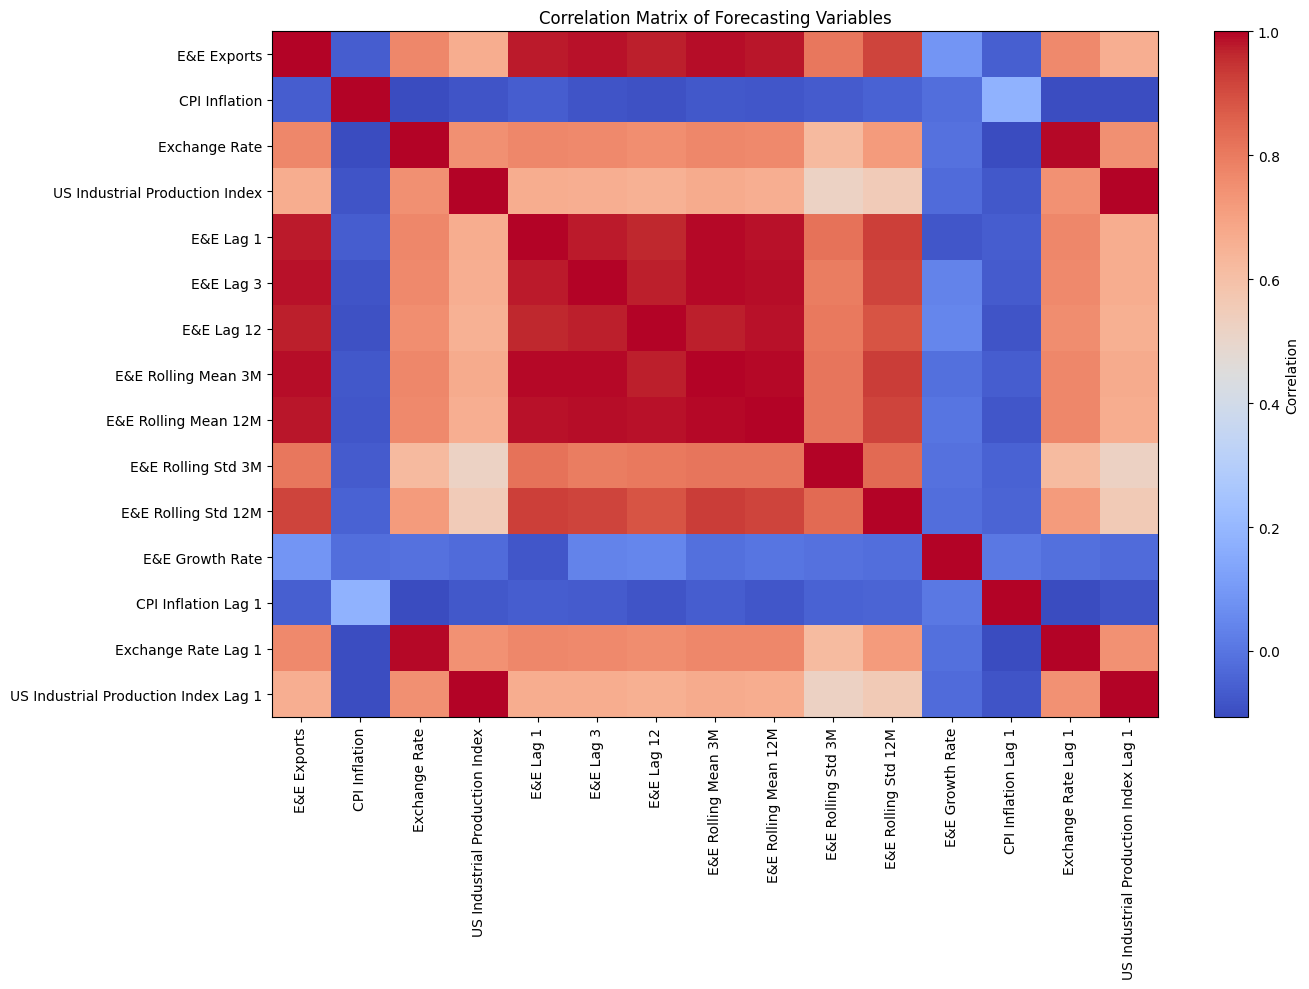

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 10))

plt.imshow(correlation_matrix, cmap='coolwarm', aspect='auto')

plt.colorbar(label='Correlation')

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title('Correlation Matrix of Forecasting Variables')

plt.tight_layout()
plt.show()

In [ ]:
df[corr_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
E&E Exports,423.0,13199.493795,10892.020419,1010.235516,5924.549925,10528.497272,16668.975955,47002.306925
CPI Inflation,423.0,0.207092,0.480715,-2.700000,0.000000,0.200000,0.300000,4.000000
Exchange Rate,423.0,3.540195,0.635804,2.439600,3.053050,3.758900,4.051250,4.765500
US Industrial Production Index,423.0,90.091065,12.916872,60.334600,85.519700,94.078800,100.160450,104.100400
E&E Lag 1,422.0,13122.208918,10788.203958,1010.235516,5918.648475,10525.813607,16648.761902,47002.306925
E&E Lag 3,420.0,13001.365116,10669.266985,1010.235516,5903.707531,10492.730610,16509.154380,47002.306925
E&E Lag 12,411.0,12400.699653,9960.963472,1010.235516,5794.804594,10398.334391,15360.685818,46277.062620
E&E Rolling Mean 3M,420.0,13092.188657,10647.065777,1098.101769,5942.909514,10515.939531,16254.350213,42994.989829
E&E Rolling Mean 12M,411.0,12914.895025,10214.518670,1180.533232,6241.986014,10469.997418,15644.259340,40434.333225
E&E Rolling Std 3M,420.0,1059.295089,1233.599509,12.768796,213.965675,579.416813,1271.729827,6422.250678


In [ ]:
df[corr_cols].isnull().sum()

,0
E&E Exports,0
CPI Inflation,0
Exchange Rate,0
US Industrial Production Index,0
E&E Lag 1,1
E&E Lag 3,3
E&E Lag 12,12
E&E Rolling Mean 3M,3
E&E Rolling Mean 12M,12
E&E Rolling Std 3M,3


In [ ]:
df[['Date', 'CPI Inflation', 'Exchange Rate',
    'US Industrial Production Index']].head(30)

,Date,CPI Inflation,Exchange Rate,US Industrial Production Index
0,1990-01-01,0.7,2.7041,61.7290
1,1990-02-01,0.5,2.7032,62.2896
2,1990-03-01,-0.2,2.7170,62.5999
3,1990-04-01,0.4,2.7264,62.4359
4,1990-05-01,0.5,2.7024,62.6258
5,1990-06-01,-0.2,2.7104,62.8382
6,1990-07-01,-0.4,2.7051,62.7284
7,1990-08-01,0.0,2.6956,62.9475
8,1990-09-01,0.5,2.6959,62.9523
9,1990-10-01,0.7,2.6995,62.5845


In [ ]:
features = [
    'E&E Lag 1',
    'E&E Lag 3',
    'E&E Lag 12',
    'E&E Rolling Mean 3M',
    'E&E Rolling Mean 12M',
    'E&E Rolling Std 3M',
    'E&E Rolling Std 12M',
    'E&E Growth Rate',
    'Month',
    'Quarter',
    'CPI Inflation Lag 1',
    'Exchange Rate Lag 1',
    'US Industrial Production Index Lag 1'
]

X = df[features].copy()

y_1M = df['Target_1M']
y_2M = df['Target_2M']
y_3M = df['Target_3M']

print("X shape:", X.shape)
print("1M target:", y_1M.shape)
print("2M target:", y_2M.shape)
print("3M target:", y_3M.shape)

X shape: (423, 13)
1M target: (423,)
2M target: (423,)
3M target: (423,)


In [ ]:
print("Missing values in X:")
print(X.isnull().sum())

print("\nMissing values in targets:")
print("1M:", y_1M.isnull().sum())
print("2M:", y_2M.isnull().sum())
print("3M:", y_3M.isnull().sum())

Missing values in X:
E&E Lag 1                                1
E&E Lag 3                                3
E&E Lag 12                              12
E&E Rolling Mean 3M                      3
E&E Rolling Mean 12M                    12
E&E Rolling Std 3M                       3
E&E Rolling Std 12M                     12
E&E Growth Rate                          1
Month                                    0
Quarter                                  0
CPI Inflation Lag 1                      1
Exchange Rate Lag 1                      1
US Industrial Production Index Lag 1     1
dtype: int64

Missing values in targets:
1M: 1
2M: 2
3M: 3


Creating Modelling Dataframe

In [ ]:
model_df = df[
    features + ['Target_1M', 'Target_2M', 'Target_3M', 'Date']
].copy()
model_df = model_df.dropna(subset=features).reset_index(drop=True)

In [ ]:
print(model_df.shape)
print(model_df['Date'].min())
print(model_df['Date'].max())

(411, 17)
1991-01-01 00:00:00
2025-03-01 00:00:00


In [ ]:
model_df[
    ['Date', 'Target_1M', 'Target_2M', 'Target_3M']
].tail(5)

,Date,Target_1M,Target_2M,Target_3M
406,2024-11-01,47002.306925,40494.054767,36504.760024
407,2024-12-01,40494.054767,36504.760024,45813.712073
408,2025-01-01,36504.760024,45813.712073,NaN
409,2025-02-01,45813.712073,NaN,NaN
410,2025-03-01,NaN,NaN,NaN


Train-Test Split

In [ ]:
model_df = df[
    features + ['Target_1M', 'Target_2M', 'Target_3M', 'Date']
].copy()

model_df = model_df.dropna(subset=features).reset_index(drop=True)

print("Model dataset shape:", model_df.shape)
print("Start date:", model_df['Date'].min())
print("End date:", model_df['Date'].max())

print("\nLast 5 rows:")
print(
    model_df[
        ['Date', 'Target_1M', 'Target_2M', 'Target_3M']
    ].tail(5)
)

Model dataset shape: (411, 17)
Start date: 1991-01-01 00:00:00
End date: 2025-03-01 00:00:00

Last 5 rows:
          Date     Target_1M     Target_2M     Target_3M
406 2024-11-01  47002.306925  40494.054767  36504.760024
407 2024-12-01  40494.054767  36504.760024  45813.712073
408 2025-01-01  36504.760024  45813.712073           NaN
409 2025-02-01  45813.712073           NaN           NaN
410 2025-03-01           NaN           NaN           NaN


In [ ]:
historical_df = model_df.dropna(
    subset=['Target_1M', 'Target_2M', 'Target_3M']
).copy()
historical_df = historical_df.reset_index(drop=True)

print("Historical dataset shape:", historical_df.shape)
print("Start:", historical_df['Date'].min())
print("End:", historical_df['Date'].max())

Historical dataset shape: (408, 17)
Start: 1991-01-01 00:00:00
End: 2024-12-01 00:00:00


Copying March 2025

In [ ]:
forecast_row = model_df[
    model_df['Date'] == '2025-03-01'
].copy()

print(forecast_row[
    ['Date'] + features
])

          Date     E&E Lag 1     E&E Lag 3   E&E Lag 12  E&E Rolling Mean 3M  \
410 2025-03-01  36504.760024  47002.306925  38699.06568         41333.707239   

     E&E Rolling Mean 12M  E&E Rolling Std 3M  E&E Rolling Std 12M  \
410          39965.305982         5298.904126          3180.931127   

     E&E Growth Rate  Month  Quarter  CPI Inflation Lag 1  \
410         0.255007      3        1                  0.4   

     Exchange Rate Lag 1  US Industrial Production Index Lag 1  
410               4.4408                              101.0993  


In [ ]:
split_index = int(len(historical_df) * 0.80)
train_df = historical_df.iloc[:split_index].copy()
test_df = historical_df.iloc[split_index:].copy()

print("Training observations:", len(train_df))
print("Testing observations:", len(test_df))
print("\nTraining period:")
print(train_df['Date'].min(), "to", train_df['Date'].max())
print("\nTesting period:")
print(test_df['Date'].min(), "to", test_df['Date'].max())

Training observations: 326
Testing observations: 82

Training period:
1991-01-01 00:00:00 to 2018-02-01 00:00:00

Testing period:
2018-03-01 00:00:00 to 2024-12-01 00:00:00


In [ ]:
X_train = train_df[features]
X_test = test_df[features]

y_train_1M = train_df['Target_1M']
y_test_1M = test_df['Target_1M']

y_train_2M = train_df['Target_2M']
y_test_2M = test_df['Target_2M']

y_train_3M = train_df['Target_3M']
y_test_3M = test_df['Target_3M']

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("1M:", y_train_1M.shape, y_test_1M.shape)
print("2M:", y_train_2M.shape, y_test_2M.shape)
print("3M:", y_train_3M.shape, y_test_3M.shape)

X_train: (326, 13)
X_test: (82, 13)
1M: (326,) (82,)
2M: (326,) (82,)
3M: (326,) (82,)


Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape:", X_test_scaled.shape)

Scaled training shape: (326, 13)
Scaled testing shape: (82, 13)


ARIMA Baseline Model

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

# Get 'E&E Exports' from the original df for the dates present in train_df
arima_train = df[df['Date'].isin(train_df['Date'])].set_index('Date')['E&E Exports'].copy()

print(arima_train.head())
print(arima_train.tail())
print("Training observations:", len(arima_train))

Date
1991-01-01    1244.326721
1991-02-01    1154.457883
1991-03-01    1383.588405
1991-04-01    1131.184118
1991-05-01    1443.263995
Name: E&E Exports, dtype: float64
Date
2017-10-01    21968.495582
2017-11-01    22253.154248
2017-12-01    20207.159071
2018-01-01    23840.024468
2018-02-01    17835.533606
Name: E&E Exports, dtype: float64
Training observations: 326


In [ ]:
import warnings
warnings.filterwarnings('ignore')
orders = [
    (1, 1, 0),
    (1, 1, 1),
    (2, 1, 0),
    (2, 1, 1),
    (2, 1, 2),
    (3, 1, 1)
]
arima_results = []
for order in orders:
    try:
        model = ARIMA(arima_train, order=order)
        fitted_model = model.fit()

        arima_results.append({
            'Order': order,
            'AIC': fitted_model.aic
        })
    except Exception as e:
        print(f"ARIMA{order} failed: {e}")
arima_results_df = pd.DataFrame(arima_results)
arima_results_df = arima_results_df.sort_values(
    'AIC'
).reset_index(drop=True)

print(arima_results_df)

       Order          AIC
0  (2, 1, 2)  5354.802449
1  (2, 1, 1)  5356.884814
2  (3, 1, 1)  5357.152032
3  (2, 1, 0)  5357.891546
4  (1, 1, 1)  5364.604053
5  (1, 1, 0)  5373.979866


choose lowest AIC

In [ ]:
import numpy as np
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA

In [ ]:
arima_order = (2, 1, 2)
arima_predictions = []
history = arima_train.copy()
for i in range(len(test_df)):
    model = ARIMA(
        history,
        order=arima_order
    )
    fitted_model = model.fit()
    forecast = fitted_model.forecast(steps=3)
    arima_predictions.append({
        'Date': test_df.iloc[i]['Date'],
        'Actual_1M': test_df.iloc[i]['Target_1M'],
        'Actual_2M': test_df.iloc[i]['Target_2M'],
        'Actual_3M': test_df.iloc[i]['Target_3M'],
        'Predicted_1M': forecast.iloc[0],
        'Predicted_2M': forecast.iloc[1],
        'Predicted_3M': forecast.iloc[2]
    })

    # Add the current actual E&E export to the history for the next prediction step
    current_date = test_df.iloc[i]['Date']
    current_actual_export = df[df['Date'] == current_date]['E&E Exports'].iloc[0]

    # Create a Series to concatenate, indexed by Date
    new_data_point = pd.Series(
        [current_actual_export],
        index=[current_date],
        name='E&E Exports'
    )
    history = pd.concat([history, new_data_point])

In [ ]:
arima_results = pd.DataFrame(arima_predictions)

print(arima_results.head())
print(arima_results.tail())

        Date     Actual_1M     Actual_2M     Actual_3M  Predicted_1M  \
0 2018-03-01  23398.591161  21023.466644  21230.045108  20201.404952   
1 2018-04-01  21023.466644  21230.045108  25895.497359  21362.507946   
2 2018-05-01  21230.045108  25895.497359  22850.859076  21390.481812   
3 2018-06-01  25895.497359  22850.859076  24012.597280  22992.714295   
4 2018-07-01  22850.859076  24012.597280  28941.709307  21894.123241   

   Predicted_2M  Predicted_3M  
0  20402.768572  19016.269323  
1  20689.603782  21924.213930  
2  23132.236445  22813.010934  
3  22610.620747  21873.697707  
4  20973.843437  21315.682631  
         Date     Actual_1M     Actual_2M     Actual_3M  Predicted_1M  \
77 2024-08-01  44006.856395  39226.126364  39795.672590  39350.135742   
78 2024-09-01  39226.126364  39795.672590  47002.306925  41578.236152   
79 2024-10-01  39795.672590  47002.306925  40494.054767  41061.402299   
80 2024-11-01  47002.306925  40494.054767  36504.760024  40491.110090   
81 2024-12

In [ ]:
#ARIMA Model Performance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [ ]:
arima_metrics = []

for horizon in ['1M', '2M', '3M']:

    actual = arima_results[f'Actual_{horizon}']
    predicted = arima_results[f'Predicted_{horizon}']

    mae = mean_absolute_error(actual, predicted)
    mse = mean_squared_error(actual, predicted)
    rmse = np.sqrt(mse)
    r2 = r2_score(actual, predicted)

    arima_metrics.append({
        'Horizon': horizon,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2
    })

arima_metrics_df = pd.DataFrame(arima_metrics)

print(arima_metrics_df)

  Horizon          MAE           MSE         RMSE        R2
0      1M  3456.952782  1.949822e+07  4415.679004  0.689557
1      2M  3681.933549  2.215601e+07  4707.017343  0.644172
2      3M  4255.420156  2.819479e+07  5309.876349  0.553866


Random Forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
rf_1M = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_1M.fit(X_train, y_train_1M)

rf_pred_1M = rf_1M.predict(X_test)

print("1M predictions:", rf_pred_1M.shape)

1M predictions: (82,)


In [ ]:
rf_2M = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_2M.fit(X_train, y_train_2M)

rf_pred_2M = rf_2M.predict(X_test)

print("2M predictions:", rf_pred_2M.shape)

2M predictions: (82,)


In [ ]:
rf_3M = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_3M.fit(X_train, y_train_3M)

rf_pred_3M = rf_3M.predict(X_test)

print("3M predictions:", rf_pred_3M.shape)

3M predictions: (82,)


In [ ]:
rf_results = pd.DataFrame({
    'Date': test_df['Date'].values,

    'Actual_1M': y_test_1M.values,
    'Predicted_1M': rf_pred_1M,

    'Actual_2M': y_test_2M.values,
    'Predicted_2M': rf_pred_2M,

    'Actual_3M': y_test_3M.values,
    'Predicted_3M': rf_pred_3M
})

print(rf_results.head())

        Date     Actual_1M  Predicted_1M     Actual_2M  Predicted_2M  \
0 2018-03-01  23398.591161  20614.515944  21023.466644  21130.434713   
1 2018-04-01  21023.466644  21627.242696  21230.045108  22592.189885   
2 2018-05-01  21230.045108  21784.228047  25895.497359  21000.083760   
3 2018-06-01  25895.497359  21739.501843  22850.859076  22088.567164   
4 2018-07-01  22850.859076  21698.674319  24012.597280  22206.123857   

      Actual_3M  Predicted_3M  
0  21230.045108  22223.358901  
1  25895.497359  22038.998440  
2  22850.859076  21834.962083  
3  24012.597280  22377.473044  
4  28941.709307  22344.535042  


In [ ]:
rf_metrics = []

for horizon in ['1M', '2M', '3M']:

    actual = rf_results[f'Actual_{horizon}']
    predicted = rf_results[f'Predicted_{horizon}']

    mae = mean_absolute_error(actual, predicted)
    mse = mean_squared_error(actual, predicted)
    rmse = np.sqrt(mse)
    r2 = r2_score(actual, predicted)

    rf_metrics.append({
        'Horizon': horizon,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2
    })

rf_metrics_df = pd.DataFrame(rf_metrics)

print(rf_metrics_df)

  Horizon           MAE           MSE          RMSE        R2
0      1M   9999.544076  1.553449e+08  12463.741533 -1.473339
1      2M  10559.185079  1.674557e+08  12940.467236 -1.689357
2      3M  10933.101163  1.788719e+08  13374.300637 -1.830341


SVR

In [ ]:
from sklearn.svm import SVR

In [ ]:
svr_1M = SVR(
    kernel='rbf',
    C=100,
    gamma='scale',
    epsilon=0.1
)

svr_1M.fit(X_train_scaled, y_train_1M)

svr_pred_1M = svr_1M.predict(X_test_scaled)

print("1M predictions:", svr_pred_1M.shape)

1M predictions: (82,)


In [ ]:
svr_2M = SVR(
    kernel='rbf',
    C=100,
    gamma='scale',
    epsilon=0.1
)

svr_2M.fit(X_train_scaled, y_train_2M)

svr_pred_2M = svr_2M.predict(X_test_scaled)

print("2M predictions:", svr_pred_2M.shape)

2M predictions: (82,)


In [ ]:
svr_3M = SVR(
    kernel='rbf',
    C=100,
    gamma='scale',
    epsilon=0.1
)

svr_3M.fit(X_train_scaled, y_train_3M)

svr_pred_3M = svr_3M.predict(X_test_scaled)

print("3M predictions:", svr_pred_3M.shape)

3M predictions: (82,)


In [ ]:
svr_results = pd.DataFrame({
    'Date': test_df['Date'].values,

    'Actual_1M': y_test_1M.values,
    'Predicted_1M': svr_pred_1M,

    'Actual_2M': y_test_2M.values,
    'Predicted_2M': svr_pred_2M,

    'Actual_3M': y_test_3M.values,
    'Predicted_3M': svr_pred_3M
})

print(svr_results.head())

        Date     Actual_1M  Predicted_1M     Actual_2M  Predicted_2M  \
0 2018-03-01  23398.591161   8595.993136  21023.466644   8784.758319   
1 2018-04-01  21023.466644   8561.927528  21230.045108   8749.084237   
2 2018-05-01  21230.045108   8696.596848  25895.497359   8884.334972   
3 2018-06-01  25895.497359  10032.041693  22850.859076  10215.663698   
4 2018-07-01  22850.859076   9034.769904  24012.597280   9214.207466   

      Actual_3M  Predicted_3M  
0  21230.045108   8918.271524  
1  25895.497359   8879.812141  
2  22850.859076   9011.288488  
3  24012.597280  10328.005142  
4  28941.709307   9353.287070  


In [ ]:
svr_metrics = []

for horizon in ['1M', '2M', '3M']:

    actual = svr_results[f'Actual_{horizon}']
    predicted = svr_results[f'Predicted_{horizon}']

    mae = mean_absolute_error(actual, predicted)
    mse = mean_squared_error(actual, predicted)
    rmse = np.sqrt(mse)
    r2 = r2_score(actual, predicted)

    svr_metrics.append({
        'Horizon': horizon,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2
    })

svr_metrics_df = pd.DataFrame(svr_metrics)

print(svr_metrics_df)

  Horizon           MAE           MSE          RMSE        R2
0      1M  23209.659954  6.028578e+08  24553.162495 -8.598463
1      2M  23183.335633  6.013208e+08  24521.843413 -8.657280
2      3M  23353.661441  6.100630e+08  24699.453765 -8.653201


XGBoost

In [ ]:
from xgboost import XGBRegressor

In [ ]:
xgb_1M = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    n_jobs=-1,
    objective='reg:squarederror'
)

xgb_1M.fit(X_train, y_train_1M)

xgb_pred_1M = xgb_1M.predict(X_test)

print("1M predictions:", xgb_pred_1M.shape)

1M predictions: (82,)


In [ ]:
xgb_2M = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    n_jobs=-1,
    objective='reg:squarederror'
)

xgb_2M.fit(X_train, y_train_2M)

xgb_pred_2M = xgb_2M.predict(X_test)

print("2M predictions:", xgb_pred_2M.shape)

2M predictions: (82,)


In [ ]:
xgb_3M = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    n_jobs=-1,
    objective='reg:squarederror'
)

xgb_3M.fit(X_train, y_train_3M)

xgb_pred_3M = xgb_3M.predict(X_test)

print("3M predictions:", xgb_pred_3M.shape)

3M predictions: (82,)


In [ ]:
xgb_results = pd.DataFrame({
    'Date': test_df['Date'].values,

    'Actual_1M': y_test_1M.values,
    'Predicted_1M': xgb_pred_1M,

    'Actual_2M': y_test_2M.values,
    'Predicted_2M': xgb_pred_2M,

    'Actual_3M': y_test_3M.values,
    'Predicted_3M': xgb_pred_3M
})

print(xgb_results.head())

        Date     Actual_1M  Predicted_1M     Actual_2M  Predicted_2M  \
0 2018-03-01  23398.591161  18216.095703  21023.466644  20796.373047   
1 2018-04-01  21023.466644  21421.652344  21230.045108  21695.179688   
2 2018-05-01  21230.045108  23066.074219  25895.497359  20672.884766   
3 2018-06-01  25895.497359  21621.039062  22850.859076  21617.269531   
4 2018-07-01  22850.859076  18094.244141  24012.597280  21600.390625   

      Actual_3M  Predicted_3M  
0  21230.045108  21450.523438  
1  25895.497359  19469.046875  
2  22850.859076  20517.115234  
3  24012.597280  23173.064453  
4  28941.709307  20165.833984  


In [ ]:
xgb_metrics = []

for horizon in ['1M', '2M', '3M']:

    actual = xgb_results[f'Actual_{horizon}']
    predicted = xgb_results[f'Predicted_{horizon}']

    mae = mean_absolute_error(actual, predicted)
    mse = mean_squared_error(actual, predicted)
    rmse = np.sqrt(mse)
    r2 = r2_score(actual, predicted)

    xgb_metrics.append({
        'Horizon': horizon,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2
    })

xgb_metrics_df = pd.DataFrame(xgb_metrics)

print(xgb_metrics_df)

  Horizon           MAE           MSE          RMSE        R2
0      1M  10581.123351  1.634233e+08  12783.712566 -1.601961
1      2M  10492.193725  1.655184e+08  12865.395684 -1.658244
2      3M  11439.339821  1.892270e+08  13755.980655 -1.994193


In [ ]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\nFeatures:")
print(X_train.columns.tolist())

print("\nTraining dates:")
print(train_df['Date'].min(), "to", train_df['Date'].max())

print("\nTesting dates:")
print(test_df['Date'].min(), "to", test_df['Date'].max())

X_train shape: (326, 13)
X_test shape: (82, 13)

Features:
['E&E Lag 1', 'E&E Lag 3', 'E&E Lag 12', 'E&E Rolling Mean 3M', 'E&E Rolling Mean 12M', 'E&E Rolling Std 3M', 'E&E Rolling Std 12M', 'E&E Growth Rate', 'Month', 'Quarter', 'CPI Inflation Lag 1', 'Exchange Rate Lag 1', 'US Industrial Production Index Lag 1']

Training dates:
1991-01-01 00:00:00 to 2018-02-01 00:00:00

Testing dates:
2018-03-01 00:00:00 to 2024-12-01 00:00:00


In [ ]:
print("\nMissing values in X_train:")
print(X_train.isna().sum())

print("\nMissing values in X_test:")
print(X_test.isna().sum())


Missing values in X_train:
E&E Lag 1                               0
E&E Lag 3                               0
E&E Lag 12                              0
E&E Rolling Mean 3M                     0
E&E Rolling Mean 12M                    0
E&E Rolling Std 3M                      0
E&E Rolling Std 12M                     0
E&E Growth Rate                         0
Month                                   0
Quarter                                 0
CPI Inflation Lag 1                     0
Exchange Rate Lag 1                     0
US Industrial Production Index Lag 1    0
dtype: int64

Missing values in X_test:
E&E Lag 1                               0
E&E Lag 3                               0
E&E Lag 12                              0
E&E Rolling Mean 3M                     0
E&E Rolling Mean 12M                    0
E&E Rolling Std 3M                      0
E&E Rolling Std 12M                     0
E&E Growth Rate                         0
Month                                   0
Quarter 

In [ ]:
print(df[
    [
        'Date',
        'E&E Exports',
        'Target_1M',
        'Target_2M',
        'Target_3M',
        'E&E Lag 1',
        'E&E Lag 3',
        'E&E Lag 12',
        'E&E Rolling Mean 3M',
        'E&E Rolling Mean 12M',
        'E&E Growth Rate'
    ]
].tail(10))

          Date   E&E Exports     Target_1M     Target_2M     Target_3M  \
413 2024-06-01  41083.016724  39357.590921  39863.748126  44006.856395   
414 2024-07-01  39357.590921  39863.748126  44006.856395  39226.126364   
415 2024-08-01  39863.748126  44006.856395  39226.126364  39795.672590   
416 2024-09-01  44006.856395  39226.126364  39795.672590  47002.306925   
417 2024-10-01  39226.126364  39795.672590  47002.306925  40494.054767   
418 2024-11-01  39795.672590  47002.306925  40494.054767  36504.760024   
419 2024-12-01  47002.306925  40494.054767  36504.760024  45813.712073   
420 2025-01-01  40494.054767  36504.760024  45813.712073           NaN   
421 2025-02-01  36504.760024  45813.712073           NaN           NaN   
422 2025-03-01  45813.712073           NaN           NaN           NaN   

        E&E Lag 1     E&E Lag 3    E&E Lag 12  E&E Rolling Mean 3M  \
413  38900.391369  38699.065680  44363.583198         37416.512983   
414  41083.016724  34650.081900  41857.607020

In [ ]:
print(
    df[
        [
            'Date',
            'CPI Inflation',
            'Exchange Rate',
            'US Industrial Production Index',
            'CPI Inflation Lag 1',
            'Exchange Rate Lag 1',
            'US Industrial Production Index Lag 1'
        ]
    ].tail(10)
)

          Date  CPI Inflation  Exchange Rate  US Industrial Production Index  \
413 2024-06-01            0.2         4.7095                        100.8940   
414 2024-07-01            0.1         4.6756                         99.9757   
415 2024-08-01            0.1         4.4120                        100.4309   
416 2024-09-01            0.0         4.2558                         99.8084   
417 2024-10-01            0.2         4.2981                         99.4695   
418 2024-11-01           -0.1         4.4342                         99.2925   
419 2024-12-01            0.1         4.4579                        100.3273   
420 2025-01-01            0.1         4.4620                        100.0647   
421 2025-02-01            0.4         4.4408                        101.0993   
422 2025-03-01            0.0         4.4325                        101.0404   

     CPI Inflation Lag 1  Exchange Rate Lag 1  \
413                  0.3               4.7158   
414                  

Random Forest Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
tscv = TimeSeriesSplit(n_splits=5)
print(tscv)
rf_param_grid = {
    'n_estimators': [200, 300, 500],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None)


In [ ]:
rf_grid_1M = GridSearchCV(
    estimator=RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ),
    param_grid=rf_param_grid,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

rf_grid_1M.fit(X_train, y_train_1M)

print("Best parameters for 1M:")
print(rf_grid_1M.best_params_)

print("Best CV RMSE for 1M:")
print(-rf_grid_1M.best_score_)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best parameters for 1M:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best CV RMSE for 1M:
2772.1221774174182


In [ ]:
rf_grid_2M = GridSearchCV(
    estimator=RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ),
    param_grid=rf_param_grid,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

rf_grid_2M.fit(X_train, y_train_2M)

print("Best parameters for 2M:")
print(rf_grid_2M.best_params_)

print("Best CV RMSE for 2M:")
print(-rf_grid_2M.best_score_)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best parameters for 2M:
{'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV RMSE for 2M:
2905.750651798064


In [ ]:
rf_grid_3M = GridSearchCV(
    estimator=RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ),
    param_grid=rf_param_grid,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

rf_grid_3M.fit(X_train, y_train_3M)

print("Best parameters for 3M:")
print(rf_grid_3M.best_params_)

print("Best CV RMSE for 3M:")
print(-rf_grid_3M.best_score_)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best parameters for 3M:
{'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 500}
Best CV RMSE for 3M:
3116.9918373893292


In [ ]:
rf_tuned_pred_1M = rf_grid_1M.best_estimator_.predict(X_test)

In [ ]:
rf_tuned_pred_2M = rf_grid_2M.best_estimator_.predict(X_test)

In [ ]:
rf_tuned_pred_3M = rf_grid_3M.best_estimator_.predict(X_test)

In [ ]:
rf_tuned_results = pd.DataFrame({
    'Date': test_df['Date'].values,

    'Actual_1M': y_test_1M.values,
    'Predicted_1M': rf_tuned_pred_1M,

    'Actual_2M': y_test_2M.values,
    'Predicted_2M': rf_tuned_pred_2M,

    'Actual_3M': y_test_3M.values,
    'Predicted_3M': rf_tuned_pred_3M
})

print(rf_tuned_results.head())

        Date     Actual_1M  Predicted_1M     Actual_2M  Predicted_2M  \
0 2018-03-01  23398.591161  20614.515944  21023.466644  21225.621946   
1 2018-04-01  21023.466644  21627.242696  21230.045108  22427.196559   
2 2018-05-01  21230.045108  21784.228047  25895.497359  20898.808356   
3 2018-06-01  25895.497359  21739.501843  22850.859076  22287.515140   
4 2018-07-01  22850.859076  21698.674319  24012.597280  22403.612194   

      Actual_3M  Predicted_3M  
0  21230.045108  22300.168187  
1  25895.497359  22194.506319  
2  22850.859076  21958.387449  
3  24012.597280  22420.448544  
4  28941.709307  22328.280880  


In [ ]:
rf_tuned_metrics = []

for horizon in ['1M', '2M', '3M']:

    actual = rf_tuned_results[f'Actual_{horizon}']
    predicted = rf_tuned_results[f'Predicted_{horizon}']

    mae = mean_absolute_error(actual, predicted)
    mse = mean_squared_error(actual, predicted)
    rmse = np.sqrt(mse)
    r2 = r2_score(actual, predicted)

    rf_tuned_metrics.append({
        'Horizon': horizon,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2
    })

rf_tuned_metrics_df = pd.DataFrame(rf_tuned_metrics)

print(rf_tuned_metrics_df)

  Horizon           MAE           MSE          RMSE        R2
0      1M   9999.544076  1.553449e+08  12463.741533 -1.473339
1      2M  10535.141644  1.666945e+08  12911.022134 -1.677132
2      3M  10826.814677  1.755632e+08  13250.027182 -1.777987


Tune SVR

In [ ]:
svr_param_grid = {
    'C': [10, 100, 500, 1000],
    'gamma': ['scale', 0.001, 0.01, 0.1],
    'epsilon': [0.01, 0.1, 0.5],
    'kernel': ['rbf']
}

In [ ]:
svr_grid_1M = GridSearchCV(
    estimator=SVR(),
    param_grid=svr_param_grid,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

svr_grid_1M.fit(X_train_scaled, y_train_1M)

print("Best parameters for SVR 1M:")
print(svr_grid_1M.best_params_)

print("Best CV RMSE for SVR 1M:")
print(-svr_grid_1M.best_score_)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best parameters for SVR 1M:
{'C': 1000, 'epsilon': 0.5, 'gamma': 0.01, 'kernel': 'rbf'}
Best CV RMSE for SVR 1M:
2542.882000413567


In [ ]:
svr_grid_2M = GridSearchCV(
    estimator=SVR(),
    param_grid=svr_param_grid,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

svr_grid_2M.fit(X_train_scaled, y_train_2M)

print("Best parameters for SVR 2M:")
print(svr_grid_2M.best_params_)

print("Best CV RMSE for SVR 2M:")
print(-svr_grid_2M.best_score_)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best parameters for SVR 2M:
{'C': 1000, 'epsilon': 0.5, 'gamma': 0.01, 'kernel': 'rbf'}
Best CV RMSE for SVR 2M:
2531.793578281696


In [ ]:
svr_grid_3M = GridSearchCV(
    estimator=SVR(),
    param_grid=svr_param_grid,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

svr_grid_3M.fit(X_train_scaled, y_train_3M)

print("Best parameters for SVR 3M:")
print(svr_grid_3M.best_params_)

print("Best CV RMSE for SVR 3M:")
print(-svr_grid_3M.best_score_)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best parameters for SVR 3M:
{'C': 1000, 'epsilon': 0.5, 'gamma': 0.01, 'kernel': 'rbf'}
Best CV RMSE for SVR 3M:
2594.0020834752495


In [ ]:
svr_tuned_pred_1M = svr_grid_1M.best_estimator_.predict(X_test_scaled)

In [ ]:
svr_tuned_pred_2M = svr_grid_2M.best_estimator_.predict(X_test_scaled)

In [ ]:
svr_tuned_pred_3M = svr_grid_3M.best_estimator_.predict(X_test_scaled)

In [ ]:
svr_tuned_results = pd.DataFrame({
    'Date': test_df['Date'].values,

    'Actual_1M': y_test_1M.values,
    'Predicted_1M': svr_tuned_pred_1M,

    'Actual_2M': y_test_2M.values,
    'Predicted_2M': svr_tuned_pred_2M,

    'Actual_3M': y_test_3M.values,
    'Predicted_3M': svr_tuned_pred_3M
})

print(svr_tuned_results.head())

        Date     Actual_1M  Predicted_1M     Actual_2M  Predicted_2M  \
0 2018-03-01  23398.591161  16089.240022  21023.466644  16976.953175   
1 2018-04-01  21023.466644  16511.295930  21230.045108  17566.315801   
2 2018-05-01  21230.045108  16684.623843  25895.497359  17731.409416   
3 2018-06-01  25895.497359  18810.340546  22850.859076  19425.240508   
4 2018-07-01  22850.859076  17513.731521  24012.597280  18005.497942   

      Actual_3M  Predicted_3M  
0  21230.045108  17492.603902  
1  25895.497359  17619.990570  
2  22850.859076  17563.784578  
3  24012.597280  19346.587265  
4  28941.709307  18344.534513  


In [ ]:
print(svr_tuned_results.head())

        Date     Actual_1M  Predicted_1M     Actual_2M  Predicted_2M  \
0 2018-03-01  23398.591161  16089.240022  21023.466644  16976.953175   
1 2018-04-01  21023.466644  16511.295930  21230.045108  17566.315801   
2 2018-05-01  21230.045108  16684.623843  25895.497359  17731.409416   
3 2018-06-01  25895.497359  18810.340546  22850.859076  19425.240508   
4 2018-07-01  22850.859076  17513.731521  24012.597280  18005.497942   

      Actual_3M  Predicted_3M  
0  21230.045108  17492.603902  
1  25895.497359  17619.990570  
2  22850.859076  17563.784578  
3  24012.597280  19346.587265  
4  28941.709307  18344.534513  


In [ ]:
svr_tuned_metrics = []

for horizon in ['1M', '2M', '3M']:

    actual = svr_tuned_results[f'Actual_{horizon}']
    predicted = svr_tuned_results[f'Predicted_{horizon}']

    mae = mean_absolute_error(actual, predicted)
    mse = mean_squared_error(actual, predicted)
    rmse = np.sqrt(mse)
    r2 = r2_score(actual, predicted)

    svr_tuned_metrics.append({
        'Horizon': horizon,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2
    })

svr_tuned_metrics_df = pd.DataFrame(svr_tuned_metrics)

print(svr_tuned_metrics_df)

  Horizon           MAE           MSE          RMSE        R2
0      1M  17565.257077  4.015766e+08  20039.375439 -5.393743
1      2M  16872.145844  3.785755e+08  19457.017380 -5.079966
2      3M  17200.327948  3.887401e+08  19716.492928 -5.151146


Tune XGBoost

In [ ]:
from xgboost import XGBRegressor

In [ ]:
xgb_param_grid = {
    'n_estimators': [200, 300, 500],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.03, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

In [ ]:
xgb_grid_1M = GridSearchCV(
    estimator=XGBRegressor(
        objective='reg:squarederror',
        random_state=42,
        n_jobs=-1
    ),
    param_grid=xgb_param_grid,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

xgb_grid_1M.fit(X_train, y_train_1M)

print("Best parameters for XGBoost 1M:")
print(xgb_grid_1M.best_params_)

print("Best CV RMSE for XGBoost 1M:")
print(-xgb_grid_1M.best_score_)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best parameters for XGBoost 1M:
{'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
Best CV RMSE for XGBoost 1M:
2454.8279582747036


In [ ]:
xgb_grid_2M = GridSearchCV(
    estimator=XGBRegressor(
        objective='reg:squarederror',
        random_state=42,
        n_jobs=-1
    ),
    param_grid=xgb_param_grid,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

xgb_grid_2M.fit(X_train, y_train_2M)

print("Best parameters for XGBoost 2M:")
print(xgb_grid_2M.best_params_)

print("Best CV RMSE for XGBoost 2M:")
print(-xgb_grid_2M.best_score_)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best parameters for XGBoost 2M:
{'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
Best CV RMSE for XGBoost 2M:
2670.9129897091143


In [ ]:
xgb_grid_3M = GridSearchCV(
    estimator=XGBRegressor(
        objective='reg:squarederror',
        random_state=42,
        n_jobs=-1
    ),
    param_grid=xgb_param_grid,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

xgb_grid_3M.fit(X_train, y_train_3M)

print("Best parameters for XGBoost 3M:")
print(xgb_grid_3M.best_params_)

print("Best CV RMSE for XGBoost 3M:")
print(-xgb_grid_3M.best_score_)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best parameters for XGBoost 3M:
{'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 500, 'subsample': 1.0}
Best CV RMSE for XGBoost 3M:
2756.330306442685


In [ ]:
xgb_tuned_pred_1M = xgb_grid_1M.best_estimator_.predict(X_test)
xgb_tuned_pred_2M = xgb_grid_2M.best_estimator_.predict(X_test)
xgb_tuned_pred_3M = xgb_grid_3M.best_estimator_.predict(X_test)

In [ ]:
xgb_tuned_results = pd.DataFrame({
    'Date': test_df['Date'].values,

    'Actual_1M': y_test_1M.values,
    'Predicted_1M': xgb_tuned_pred_1M,

    'Actual_2M': y_test_2M.values,
    'Predicted_2M': xgb_tuned_pred_2M,

    'Actual_3M': y_test_3M.values,
    'Predicted_3M': xgb_tuned_pred_3M
})

print(xgb_tuned_results.head())

        Date     Actual_1M  Predicted_1M     Actual_2M  Predicted_2M  \
0 2018-03-01  23398.591161  20370.207031  21023.466644  21084.781250   
1 2018-04-01  21023.466644  21125.335938  21230.045108  21901.128906   
2 2018-05-01  21230.045108  22167.003906  25895.497359  21027.679688   
3 2018-06-01  25895.497359  20903.564453  22850.859076  22585.337891   
4 2018-07-01  22850.859076  20465.394531  24012.597280  22206.230469   

      Actual_3M  Predicted_3M  
0  21230.045108  22593.687500  
1  25895.497359  22871.041016  
2  22850.859076  21407.685547  
3  24012.597280  23127.224609  
4  28941.709307  22404.601562  


In [ ]:
xgb_tuned_metrics = []

for horizon in ['1M', '2M', '3M']:

    actual = xgb_tuned_results[f'Actual_{horizon}']
    predicted = xgb_tuned_results[f'Predicted_{horizon}']

    mae = mean_absolute_error(actual, predicted)
    mse = mean_squared_error(actual, predicted)
    rmse = np.sqrt(mse)
    r2 = r2_score(actual, predicted)

    xgb_tuned_metrics.append({
        'Horizon': horizon,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2
    })

xgb_tuned_metrics_df = pd.DataFrame(xgb_tuned_metrics)

print(xgb_tuned_metrics_df)

  Horizon           MAE           MSE          RMSE        R2
0      1M   9854.360196  1.472308e+08  12133.872010 -1.344151
1      2M  10555.223599  1.661330e+08  12889.258618 -1.668114
2      3M  10447.967689  1.628131e+08  12759.822496 -1.576238


Evaluation

In [ ]:
import pandas as pd

final_comparison = pd.concat([
    rf_tuned_metrics_df.assign(Model='Random Forest')[['Model', 'Horizon', 'MAE', 'MSE', 'RMSE', 'R2']],
    svr_tuned_metrics_df.assign(Model='SVR')[['Model', 'Horizon', 'MAE', 'MSE', 'RMSE', 'R2']],
    xgb_tuned_metrics_df.assign(Model='XGBoost')[['Model', 'Horizon', 'MAE', 'MSE', 'RMSE', 'R2']]
], ignore_index=True)

# Order the models and horizons
model_order = ['Random Forest', 'SVR', 'XGBoost']
horizon_order = ['1M', '2M', '3M']

final_comparison['Model'] = pd.Categorical(
    final_comparison['Model'],
    categories=model_order,
    ordered=True
)

final_comparison['Horizon'] = pd.Categorical(
    final_comparison['Horizon'],
    categories=horizon_order,
    ordered=True
)

# Sort the table
final_comparison = final_comparison.sort_values(
    ['Horizon', 'Model']
).reset_index(drop=True)

# Round the values
final_comparison['MAE'] = final_comparison['MAE'].round(2)
final_comparison['MSE'] = final_comparison['MSE'].round(2)
final_comparison['RMSE'] = final_comparison['RMSE'].round(2)
final_comparison['R2'] = final_comparison['R2'].round(4)

print(final_comparison)

# Download the dataframe as a CSV file
final_comparison.to_csv('model_comparison.csv', index=False)
print("DataFrame 'final_comparison' saved as model_comparison.csv")

           Model Horizon       MAE           MSE      RMSE      R2
0  Random Forest      1M   9999.54  1.553449e+08  12463.74 -1.4733
1            SVR      1M  17565.26  4.015766e+08  20039.38 -5.3937
2        XGBoost      1M   9854.36  1.472308e+08  12133.87 -1.3442
3  Random Forest      2M  10535.14  1.666945e+08  12911.02 -1.6771
4            SVR      2M  16872.15  3.785755e+08  19457.02 -5.0800
5        XGBoost      2M  10555.22  1.661330e+08  12889.26 -1.6681
6  Random Forest      3M  10826.81  1.755632e+08  13250.03 -1.7780
7            SVR      3M  17200.33  3.887401e+08  19716.49 -5.1511
8        XGBoost      3M  10447.97  1.628131e+08  12759.82 -1.5762
DataFrame 'final_comparison' saved as model_comparison.csv


In [ ]:
# Find the best ML model for each forecasting horizon
ml_results = final_comparison[
    final_comparison['Model'].isin(['Random Forest', 'SVR', 'XGBoost'])
].copy()

best_ml_models = ml_results.loc[
    ml_results.groupby('Horizon')['RMSE'].idxmin()
].sort_values('Horizon')

print("Best ML model for each forecasting horizon:")
print(best_ml_models)

Best ML model for each forecasting horizon:
     Model Horizon       MAE           MSE      RMSE      R2
2  XGBoost      1M   9854.36  1.472308e+08  12133.87 -1.3442
5  XGBoost      2M  10555.22  1.661330e+08  12889.26 -1.6681
8  XGBoost      3M  10447.97  1.628131e+08  12759.82 -1.5762


In [ ]:
comparison_best = final_comparison[
    (final_comparison['Model'].isin(['ARIMA', 'XGBoost']))
].copy()

print(comparison_best)

     Model Horizon       MAE           MSE      RMSE      R2
2  XGBoost      1M   9854.36  1.472308e+08  12133.87 -1.3442
5  XGBoost      2M  10555.22  1.661330e+08  12889.26 -1.6681
8  XGBoost      3M  10447.97  1.628131e+08  12759.82 -1.5762


Forecast 3 month

In [ ]:
# Create final dataset for training the XGBoost forecasting models

final_model_data = model_df.copy()

# Keep only rows where all three targets are available
final_model_data = final_model_data.dropna(
    subset=['Target_1M', 'Target_2M', 'Target_3M']
).copy()

print("Final training dataset shape:", final_model_data.shape)
print("Start date:", final_model_data['Date'].min())
print("End date:", final_model_data['Date'].max())

print("\nMissing target values:")
print(final_model_data[['Target_1M', 'Target_2M', 'Target_3M']].isna().sum())

Final training dataset shape: (408, 17)
Start date: 1991-01-01 00:00:00
End date: 2024-12-01 00:00:00

Missing target values:
Target_1M    0
Target_2M    0
Target_3M    0
dtype: int64


In [ ]:
features = [
    'E&E Lag 1',
    'E&E Lag 3',
    'E&E Lag 12',
    'E&E Rolling Mean 3M',
    'E&E Rolling Mean 12M',
    'E&E Rolling Std 3M',
    'E&E Rolling Std 12M',
    'E&E Growth Rate',
    'Month',
    'Quarter',
    'CPI Inflation Lag 1',
    'Exchange Rate Lag 1',
    'US Industrial Production Index Lag 1'
]

X_final = final_model_data[features]

y_1M = final_model_data['Target_1M']
y_2M = final_model_data['Target_2M']
y_3M = final_model_data['Target_3M']

print("X_final shape:", X_final.shape)
print("1M target shape:", y_1M.shape)
print("2M target shape:", y_2M.shape)
print("3M target shape:", y_3M.shape)

X_final shape: (408, 13)
1M target shape: (408,)
2M target shape: (408,)
3M target shape: (408,)


In [ ]:
from xgboost import XGBRegressor
xgb_final_1M = XGBRegressor(
    colsample_bytree=0.8,
    learning_rate=0.1,
    max_depth=3,
    n_estimators=200,
    subsample=0.8,
    objective='reg:squarederror',
    random_state=42
)
xgb_final_2M = XGBRegressor(
    colsample_bytree=0.8,
    learning_rate=0.1,
    max_depth=3,
    n_estimators=200,
    subsample=0.8,
    objective='reg:squarederror',
    random_state=42
)
xgb_final_3M = XGBRegressor(
    colsample_bytree=0.8,
    learning_rate=0.05,
    max_depth=3,
    n_estimators=500,
    subsample=1.0,
    objective='reg:squarederror',
    random_state=42
)

In [ ]:
# Train final models using all available supervised training data

xgb_final_1M.fit(X_final, y_1M)
xgb_final_2M.fit(X_final, y_2M)
xgb_final_3M.fit(X_final, y_3M)

print("Final XGBoost models trained successfully.")

Final XGBoost models trained successfully.


In [ ]:
# Get the March 2025 feature row

march_2025 = model_df[
    model_df['Date'] == '2025-03-01'
].copy()
X_march_2025 = march_2025[features]

print("March 2025 feature shape:", X_march_2025.shape)
print("\nMarch 2025 features:")
print(X_march_2025)

March 2025 feature shape: (1, 13)

March 2025 features:
        E&E Lag 1     E&E Lag 3   E&E Lag 12  E&E Rolling Mean 3M  \
410  36504.760024  47002.306925  38699.06568         41333.707239   

     E&E Rolling Mean 12M  E&E Rolling Std 3M  E&E Rolling Std 12M  \
410          39965.305982         5298.904126          3180.931127   

     E&E Growth Rate  Month  Quarter  CPI Inflation Lag 1  \
410         0.255007      3        1                  0.4   

     Exchange Rate Lag 1  US Industrial Production Index Lag 1  
410               4.4408                              101.0993  


In [ ]:
import pandas as pd

# Generate forecasts from March 2025

forecast_1M = xgb_final_1M.predict(X_march_2025)[0]
forecast_2M = xgb_final_2M.predict(X_march_2025)[0]
forecast_3M = xgb_final_3M.predict(X_march_2025)[0]

# Create a DataFrame for the forecasts
forecast_data = {
    'Forecast Date': pd.to_datetime(['2025-04-01', '2025-05-01', '2025-06-01']),
    'Horizon': ['1M', '2M', '3M'],
    'Model': 'XGBoost',
    'Forecast': [forecast_1M, forecast_2M, forecast_3M]
}
forecast_df = pd.DataFrame(forecast_data)

print("E&E Export Forecasts:")
display(forecast_df)

# Save the forecast DataFrame as a CSV file
forecast_df.to_csv('xgboost_forecasts.csv', index=False)
print("Forecasts saved to 'xgboost_forecasts.csv'")

E&E Export Forecasts:


,Forecast Date,Horizon,Model,Forecast
0,2025-04-01,1M,XGBoost,41136.523438
1,2025-05-01,2M,XGBoost,34820.074219
2,2025-06-01,3M,XGBoost,37973.492188


Forecasts saved to 'xgboost_forecasts.csv'


Feature Importance

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Create feature importance tables
importance_1M = pd.DataFrame({
    'Feature': features,
    'Importance': xgb_final_1M.feature_importances_
}).sort_values('Importance', ascending=False)

importance_2M = pd.DataFrame({
    'Feature': features,
    'Importance': xgb_final_2M.feature_importances_
}).sort_values('Importance', ascending=False)

importance_3M = pd.DataFrame({
    'Feature': features,
    'Importance': xgb_final_3M.feature_importances_
}).sort_values('Importance', ascending=False)

print("=== 1-Month Forecast Feature Importance ===")
print(importance_1M)

print("\n=== 2-Month Forecast Feature Importance ===")
print(importance_2M)

print("\n=== 3-Month Forecast Feature Importance ===")
print(importance_3M)

=== 1-Month Forecast Feature Importance ===
                                 Feature  Importance
4                   E&E Rolling Mean 12M    0.696834
3                    E&E Rolling Mean 3M    0.123637
2                             E&E Lag 12    0.089372
0                              E&E Lag 1    0.049686
11                   Exchange Rate Lag 1    0.008525
12  US Industrial Production Index Lag 1    0.005927
8                                  Month    0.005770
1                              E&E Lag 3    0.005036
6                    E&E Rolling Std 12M    0.004382
9                                Quarter    0.003698
10                   CPI Inflation Lag 1    0.003458
5                     E&E Rolling Std 3M    0.002094
7                        E&E Growth Rate    0.001580

=== 2-Month Forecast Feature Importance ===
                                 Feature  Importance
4                   E&E Rolling Mean 12M    0.359872
3                    E&E Rolling Mean 3M    0.258977
0         

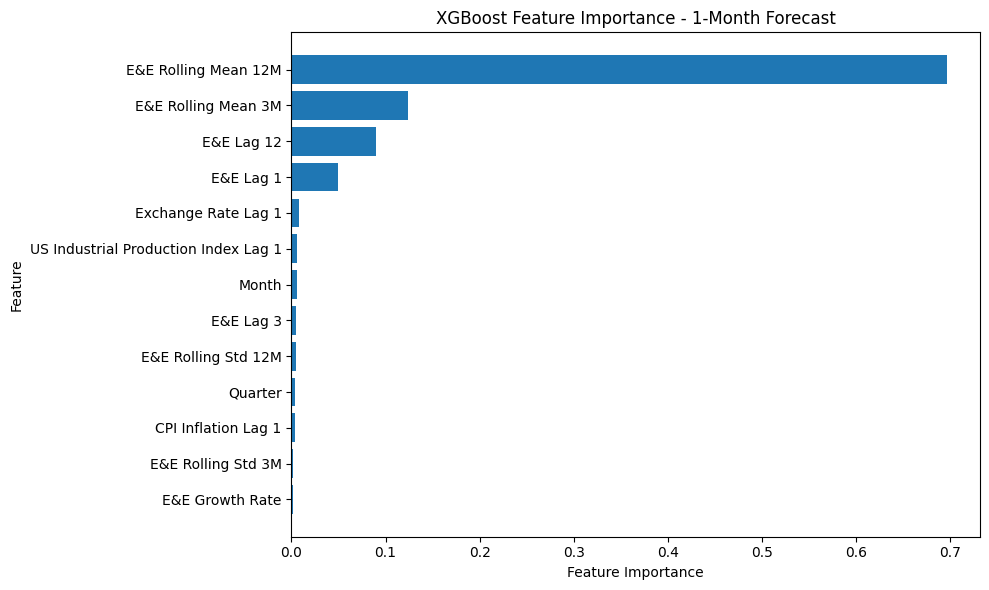

In [ ]:
plt.figure(figsize=(10, 6))

plt.barh(
    importance_1M['Feature'],
    importance_1M['Importance']
)

plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('XGBoost Feature Importance - 1-Month Forecast')

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

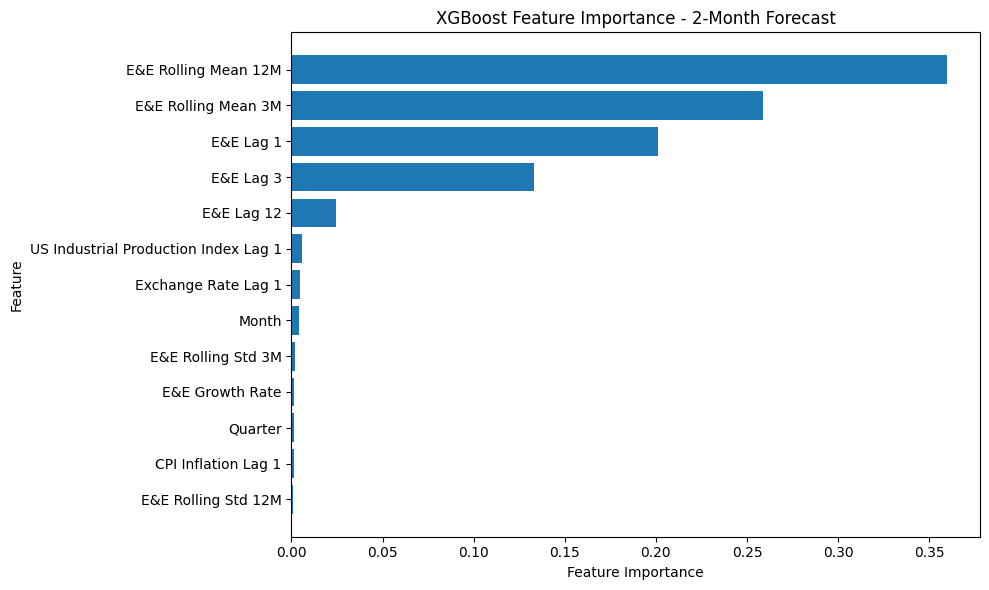

In [ ]:
# XGBoost Feature Importance - 2 Months

plt.figure(figsize=(10, 6))

plt.barh(
    importance_2M['Feature'],
    importance_2M['Importance']
)

plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('XGBoost Feature Importance - 2-Month Forecast')

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

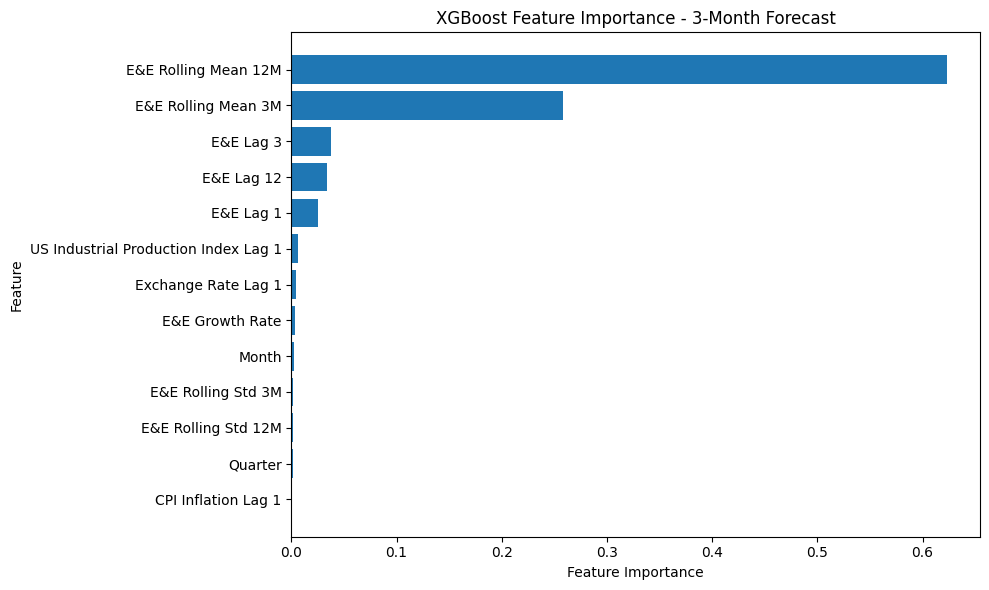

In [ ]:
# XGBoost Feature Importance - 3 Months

plt.figure(figsize=(10, 6))

plt.barh(
    importance_3M['Feature'],
    importance_3M['Importance']
)

plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('XGBoost Feature Importance - 3-Month Forecast')

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
# Combine feature importance from all three XGBoost models

feature_importance_comparison = pd.DataFrame({
    'Feature': features,
    '1M Importance': xgb_final_1M.feature_importances_,
    '2M Importance': xgb_final_2M.feature_importances_,
    '3M Importance': xgb_final_3M.feature_importances_
})

# Calculate average importance across the three horizons
feature_importance_comparison['Average Importance'] = (
    feature_importance_comparison[
        ['1M Importance', '2M Importance', '3M Importance']
    ].mean(axis=1)
)

# Sort by average importance
feature_importance_comparison = feature_importance_comparison.sort_values(
    'Average Importance',
    ascending=False
).reset_index(drop=True)

# Round values
feature_importance_comparison[
    ['1M Importance', '2M Importance', '3M Importance', 'Average Importance']
] = feature_importance_comparison[
    ['1M Importance', '2M Importance', '3M Importance', 'Average Importance']
].round(4)

# Reshape the DataFrame for display as requested by the user
feature_importance_melted = feature_importance_comparison.melt(
    id_vars=['Feature'],
    value_vars=['1M Importance', '2M Importance', '3M Importance'],
    var_name='Horizon',
    value_name='Importance'
)

# Clean up the 'Horizon' column to remove ' Importance'
feature_importance_melted['Horizon'] = feature_importance_melted['Horizon'].str.replace(' Importance', '')

# Display the melted DataFrame
display(feature_importance_melted)

# Save the melted DataFrame to a CSV file
feature_importance_melted.to_csv('feature_importance_comparison_melted.csv', index=False)
print("Feature importance data saved to 'feature_importance_comparison_melted.csv'")

,Feature,Horizon,Importance
0,E&E Rolling Mean 12M,1M,0.6968
1,E&E Rolling Mean 3M,1M,0.1236
2,E&E Lag 1,1M,0.0497
3,E&E Lag 3,1M,0.0050
4,E&E Lag 12,1M,0.0894
5,US Industrial Production Index Lag 1,1M,0.0059
6,Exchange Rate Lag 1,1M,0.0085
7,Month,1M,0.0058
8,E&E Rolling Std 12M,1M,0.0044
9,Quarter,1M,0.0037


Feature importance data saved to 'feature_importance_comparison_melted.csv'


In [ ]:
# Recent actual E&E exports
recent_actual = df[
    (df['Date'] >= '2024-10-01') &
    (df['Date'] <= '2025-03-01')
][['Date', 'E&E Exports']].copy()

# Final forecasts
future_forecasts = pd.DataFrame({
    'Date': pd.to_datetime([
        '2025-04-01',
        '2025-05-01',
        '2025-06-01'
    ]),
    'E&E Exports': [
        forecast_1M,
        forecast_2M,
        forecast_3M
    ]
})

# Combine actual and forecast
recent_and_forecast = pd.concat(
    [recent_actual, future_forecasts],
    ignore_index=True
)

print(recent_and_forecast)

        Date   E&E Exports
0 2024-10-01  39226.126364
1 2024-11-01  39795.672590
2 2024-12-01  47002.306925
3 2025-01-01  40494.054767
4 2025-02-01  36504.760024
5 2025-03-01  45813.712073
6 2025-04-01  41136.523438
7 2025-05-01  34820.074219
8 2025-06-01  37973.492188


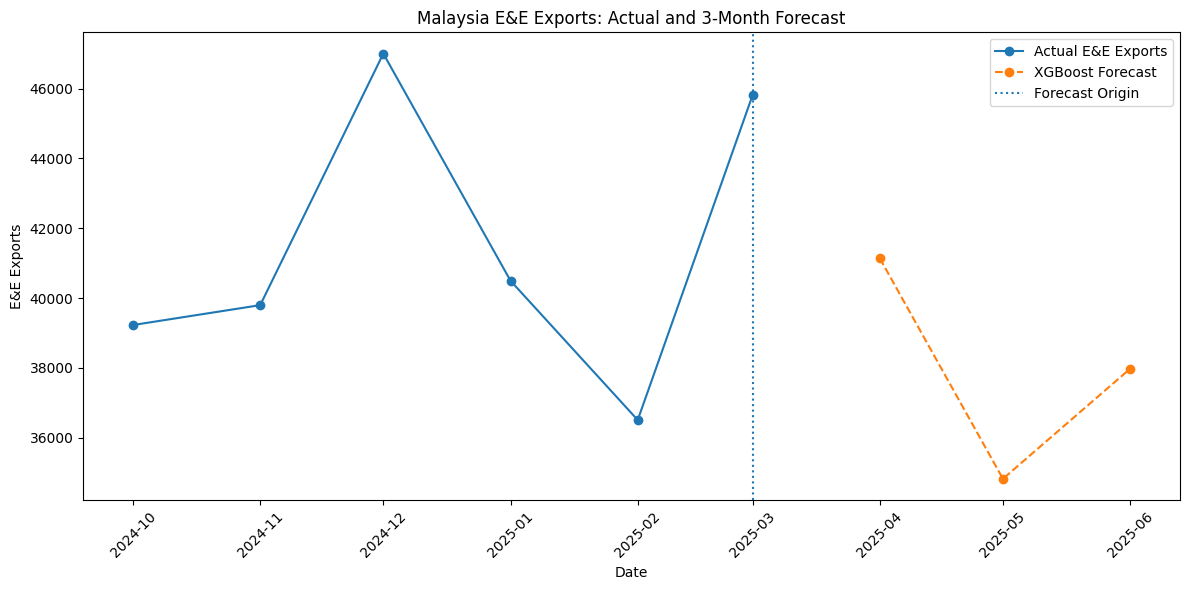

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    recent_actual['Date'],
    recent_actual['E&E Exports'],
    marker='o',
    label='Actual E&E Exports'
)

plt.plot(
    future_forecasts['Date'],
    future_forecasts['E&E Exports'],
    marker='o',
    linestyle='--',
    label='XGBoost Forecast'
)

plt.axvline(
    pd.Timestamp('2025-03-01'),
    linestyle=':',
    label='Forecast Origin'
)

plt.xlabel('Date')
plt.ylabel('E&E Exports')
plt.title('Malaysia E&E Exports: Actual and 3-Month Forecast')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
residuals_1M = (
    xgb_tuned_results['Actual_1M'] -
    xgb_tuned_results['Predicted_1M']
)

print("XGBoost 1M Residual Statistics:")
print(residuals_1M.describe())

XGBoost 1M Residual Statistics:
count       82.000000
mean      9588.123752
std       7482.074129
min      -2962.173497
25%       3023.191815
50%       8622.613784
75%      16078.634654
max      24441.529581
dtype: float64


In [ ]:
import pandas as pd

# Load the CSV files
feature_importance_df = pd.read_csv('feature_importance_comparison_melted.csv')
model_comparison_df = pd.read_csv('model_comparison.csv')
xgboost_forecasts_df = pd.read_csv('xgboost_forecasts.csv')

print("Feature Importance Data:")
display(feature_importance_df.head())
print("\nModel Comparison Data:")
display(model_comparison_df.head())
print("\nXGBoost Forecasts Data:")
display(xgboost_forecasts_df.head())


Feature Importance Data:


,Feature,Horizon,Importance
0,E&E Rolling Mean 12M,1M,0.6968
1,E&E Rolling Mean 3M,1M,0.1236
2,E&E Lag 1,1M,0.0497
3,E&E Lag 3,1M,0.0050
4,E&E Lag 12,1M,0.0894



Model Comparison Data:


,Model,Horizon,MAE,MSE,RMSE,R2
0,Random Forest,1M,9999.54,1.553449e+08,12463.74,-1.4733
1,SVR,1M,17565.26,4.015766e+08,20039.38,-5.3937
2,XGBoost,1M,9854.36,1.472308e+08,12133.87,-1.3442
3,Random Forest,2M,10535.14,1.666945e+08,12911.02,-1.6771
4,SVR,2M,16872.15,3.785755e+08,19457.02,-5.0800



XGBoost Forecasts Data:


,Forecast Date,Horizon,Model,Forecast
0,2025-04-01,1M,XGBoost,41136.523
1,2025-05-01,2M,XGBoost,34820.074
2,2025-06-01,3M,XGBoost,37973.492
